In [133]:
import numpy as np
import numpy.fft as fft
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic
from tqdm import tqdm
from numba import njit

In [134]:
def f_contour(f, x, r0, num_thetas):
    if np.isscalar(x):
        x = np.array([x])
    thetas = np.linspace(0, 2*np.pi, num_thetas)
    circle = r0 * np.exp(1j * thetas)
    f_values = f(x[:,None] + circle[None,:])
    return np.trapezoid(f_values, thetas, axis=1).real / (2*np.pi)

def interp_cic_1d(field, z, dx):
    N = field.size
    xi = z / dx
    j0 = int(np.floor(xi)) % N
    w = xi - np.floor(xi)

    j1 = (j0 + 1) % N

    return (1.0 - w) * field[j0] + w * field[j1]

def wrap_centered(y, L):
    return y - L*np.round(y/L)   # gives (-L/2, L/2]

@njit
def unwrap_periodic(z, L):
    z_unwrap = np.zeros(z.shape, dtype=float)
    z_unwrap[0] = z[0]
    for n in range(1, len(z)):
        dz = z[n] - z[n-1]
        # choose the jump in (-L/2, L/2]
        dz -= L * np.round(dz / L)
        z_unwrap[n] = z_unwrap[n-1] + dz
    return z_unwrap

In [135]:
def get_params_from_scales(field_length_scale, 
                           field_time_scale, 
                           particle_time_scale,
                           mu,
                           kappa):
    # K / mu = field_length_scale**2
    # gamma_tilde / mu = field_time_scale / field_length_scale**2
    # gamma / kappa = particle_trap_time_scale
    gamma = kappa * particle_time_scale
    K = mu * field_length_scale**2
    gamma_tilde = mu * field_time_scale / field_length_scale**2
    return {'gamma': gamma, 'K': K, 'gamma_tilde': gamma_tilde}

In [136]:
# ---- parameters of the simulation ----
dx = 0.01
N = 4096
L = N*dx
x = np.arange(N)*dx
q = 2*np.pi*fft.fftfreq(N, d=dx)
q2 = q**2
dt = 1e-4
field_length_scale = 0.03
field_time_scale = 1e-2
particle_time_scale = 1e-3
mu = 0.001
kappa = 50.0
kbT = 4.11/1000
params = get_params_from_scales(field_length_scale=field_length_scale,
                           field_time_scale=field_time_scale, 
                           particle_time_scale=particle_time_scale,
                           mu=mu,
                           kappa=kappa)
K, gamma_tilde, gamma = params['K'], params['gamma_tilde'], params['gamma']


# ---- interaction ----
coupling = 0.5
r0 = 2.5
v = 1.0

In [137]:
# ---- machinery ----
lambda_z_dt = kappa*dt/gamma
lambda_q_dt = (mu + K*q2)*(dt*q2) / gamma_tilde
exp_integrator_z = np.exp(-lambda_z_dt)
exp_integrator_q = np.exp(-lambda_q_dt)
integrator_negated = lambda x : (1-np.exp(-x)) / x
integration_factor_z = dt*f_contour(integrator_negated, lambda_z_dt, 2, num_thetas=512).item()
integration_factor_q = dt*f_contour(integrator_negated, lambda_q_dt, 2, num_thetas=512)
noise_sigma_z  = np.sqrt(f_contour(integrator_negated, 2*lambda_z_dt, 2, num_thetas=512).item()*2*kbT*dt/gamma)
noise_sigma_q  = np.sqrt(f_contour(integrator_negated, 2*lambda_q_dt, 2, num_thetas=512)*2*q2*kbT*dt/gamma_tilde)
V_x = np.exp(-0.5*(x**2)/r0**2)
V_x *= 1/(np.sum(V_x)*dx)
V_q = fft.fft(V_x)
grad_kernel_q = 1j*q*np.conjugate(V_q)
interaction_term_field = (coupling/gamma_tilde)*q2*V_q

In [138]:
n_equilibration_steps = int(10*field_time_scale/dt)
np.random.seed(42)
phi_q = np.random.randn(N)
phi_q -= np.mean(phi_q)
phi_q = fft.fft(phi_q)
phi_q[0] = 0.0
for step in tqdm(range(n_equilibration_steps)):
    noise_q = noise_sigma_q * fft.fft(np.random.randn(N)) / np.sqrt(N)
    phi_q = exp_integrator_q*phi_q + noise_q

100%|██████████| 1000/1000 [00:00<00:00, 9256.03it/s]


In [139]:
n_steps = int(3*L/(v*dt))
save_phi_every = max(1, n_steps//1000)

# state
z = 0.0

phi_qs = []
z_hist = []

for step in tqdm(range(n_steps)):
    # store
    z_hist.append(z)
    if step % save_phi_every == 0:
        phi_qs.append(phi_q.copy())

    # forces at z_n
    interaction_term_particle = fft.ifft(grad_kernel_q * phi_q).real
    force_particle = (coupling/gamma) * interp_cic_1d(interaction_term_particle, z, dx)
    force_particle += (v*dt*step % L)*kappa/gamma

    force_field = interaction_term_field * np.exp(-1j * z * q)

    # noises
    noise_q = noise_sigma_q * fft.fft(np.random.randn(N)) / np.sqrt(N)
    noise_z = noise_sigma_z * np.random.randn()

    z = exp_integrator_z*z + integration_factor_z*force_particle + noise_z
    z = z % L

    # update field (explicit in z_n)
    phi_q = exp_integrator_q*phi_q + integration_factor_q*force_field + noise_q

phi_qs = np.array(phi_qs)
z_hist = np.array(z_hist)

100%|██████████| 1228800/1228800 [04:47<00:00, 4280.42it/s]


In [140]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# reconstruct real-space field
phi_xs = np.real(np.fft.ifft(phi_qs, axis=1))

n_frames = phi_xs.shape[0]

fig, ax = plt.subplots(figsize=(8,4))
field_plot, = ax.plot(x, phi_xs[0])
particle_plot = ax.scatter(z_hist[0], 0, color='red', zorder=5)
trap_pos_plot = ax.scatter(0, 0, color='green', zorder=5, s=10)
ax.set_xlim(0, L)
ax.set_ylim(phi_xs.min(), phi_xs.max())
ax.set_xlabel("x")
ax.set_ylabel("phi")

def update(frame):
    field_plot.set_ydata(phi_xs[frame])
    particle_plot.set_offsets(np.array([[z_hist[frame*save_phi_every], 0]]))
    trap_pos_plot.set_offsets(np.array([[v*dt*frame*save_phi_every % L, 0]]) )
    ax.set_title(f"frame {frame}")
    return field_plot, particle_plot, trap_pos_plot

ani = FuncAnimation(fig, update, frames=n_frames, interval=50)
ani.save("field_evolution.mp4", fps=20, dpi=150)
plt.close()

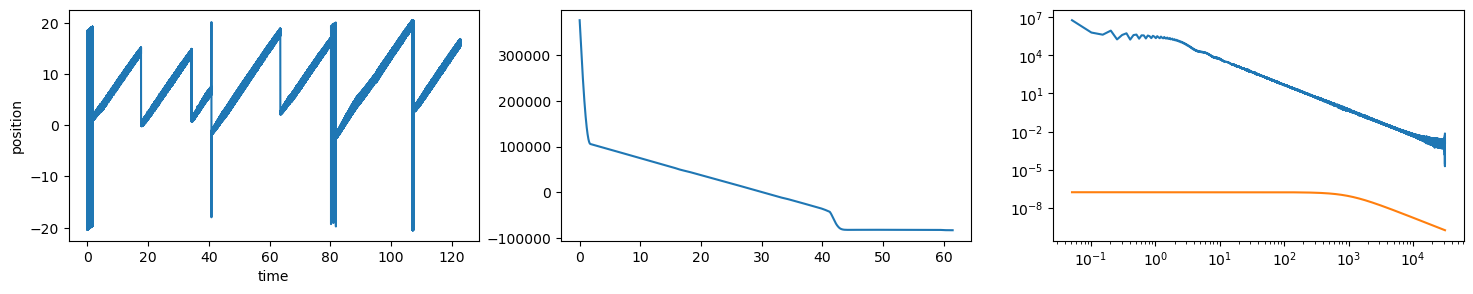

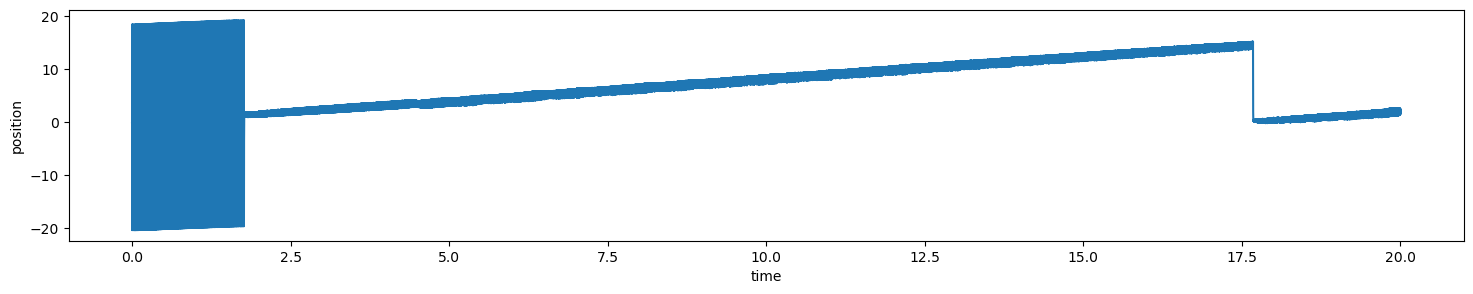

In [142]:
skip_initial_time = int(10*field_time_scale/dt)
skip_final_time = int(field_time_scale/dt)
unwrapped_u_series = np.arange(z_hist.size)*v*dt - unwrap_periodic(z_hist, L)
centered_u_series = wrap_centered(unwrapped_u_series, L)
unwrapped_u_series = unwrapped_u_series[skip_initial_time:-skip_final_time]
centered_u_series = centered_u_series[skip_initial_time:-skip_final_time]
t = np.arange(centered_u_series.size)*dt
flucts = unwrapped_u_series - np.mean(unwrapped_u_series)
omega = 2*np.pi*fft.fftfreq(centered_u_series.size, d=dt)
flucts_omega = fft.fft(flucts)                        
acf = fft.ifft( (np.conjugate(flucts_omega)*flucts_omega)).real/flucts.size
fig, axs = plt.subplots(ncols=3, figsize=(18,3))
axs[0].plot(t, centered_u_series)
axs[0].set_xlabel('time')
axs[0].set_ylabel('position')
omega_mask = omega > 0
axs[1].plot( t[:n_steps//2], acf[:n_steps//2])
axs[2].plot(omega[omega_mask], dt*(np.conjugate(flucts_omega[omega_mask])*flucts_omega[omega_mask]).real/flucts.size)
axs[2].plot(omega[omega_mask], (2*kbT/gamma)/( 1/particle_time_scale**2.0 +  omega[omega_mask]**2))
axs[2].set_xscale('log')
axs[2].set_yscale('log')
plt.show()


fig, ax = plt.subplots(figsize=(18,3))
idx = 200000
ax.plot(t[:idx], centered_u_series[:idx])
ax.set_xlabel('time')
ax.set_ylabel('position')
plt.show()

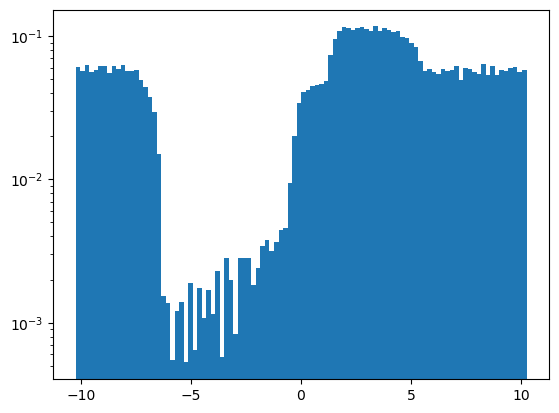

In [132]:
plt.hist(centered_u_series, bins=100, density=True)
plt.yscale('log')
plt.show()

In [ ]:
import numpy as np

# Assumes these are already defined:
# L, v, r0, mu, K, gamma_tilde, particle_time_scale

max_length = 10 * L
max_time = particle_time_scale * 1e4

delta_t = np.linspace(-max_time, max_time, 200)   # (T,)
delta_u = np.linspace(-max_length, max_length, 200)  # (U,)

# -------------------------------------------------------------------
# Adaptive q cutoff
# -------------------------------------------------------------------
eps_tail = 1e-12
log_tail = np.log(1.0 / eps_tail)

abs_dt = np.abs(delta_t)

# Quadratic damping scale: exp[-a_t q^2]
a_t = r0**2 + (mu / gamma_tilde) * abs_dt  # (T,)
a_min = np.min(a_t)  # worst-case (smallest damping)

# q where exp(-a_min q^2) ~ eps_tail
q_max_quad = np.sqrt(log_tail / max(a_min, 1e-300))

# Quartic damping scale: exp[-b_t q^4]
b_t = (K / gamma_tilde) * abs_dt  # (T,)

# ignore exact zeros (typically at dt=0), since quartic damping vanishes there
positive_b = b_t[b_t > 0]
if positive_b.size > 0:
    b_min = np.min(positive_b)  # weakest nonzero quartic damping
    q_max_quart = (log_tail / max(b_min, 1e-300))**0.25
else:
    q_max_quart = 0.0

# Use the largest relevant cutoff
q_max = max(q_max_quad, q_max_quart)

# Optional safety cap if something goes pathological
q_max = min(q_max, 1e4)

# Use enough points to resolve oscillations and keep odd/even symmetry nice
n_q = 5001
q = np.linspace(-q_max, q_max, n_q)  # (Q,)

# -------------------------------------------------------------------
# Build integrand
# -------------------------------------------------------------------
q2 = q**2
q4 = q2**2

# Explicit broadcasted views
dt3 = delta_t[:, None, None]      # (T,1,1)
du3 = delta_u[None, :, None]      # (1,U,1)
q3  = q[None, None, :]            # (1,1,Q)

a3 = a_t[:, None, None]           # (T,1,1)
b3 = b_t[:, None, None]           # (T,1,1)

# Conserved-noise prefactor
prefactor = q2 / (mu + K * q2)    # (Q,)
pref3 = prefactor[None, None, :]  # (1,1,Q)

# Damping factors
gauss3 = np.exp(-a3 * q3**2)      # (T,1,Q)
quartic3 = np.exp(-b3 * q3**4)    # (T,1,Q)

# Phase: q * (v * delta_t + delta_u)
phase = q3 * (v * dt3 + du3)      # (T,U,Q)

integrand = pref3 * gauss3 * quartic3 * np.cos(phase)  # (T,U,Q)

corr_func = np.trapezoid(integrand, q, axis=-1) / (2.0 * np.pi)
# shape: (len(delta_t), len(delta_u))

print("q_max =", q_max)
print("integrand shape:", integrand.shape)
print("corr_func shape:", corr_func.shape)

%matplotlib qt
fig = plt.figure()
ax3d = fig.add_subplot(111, projection='3d')
X, Y = np.meshgrid(delta_t, delta_u)
ax3d.plot_surface(X, Y, corr_func.T, cmap='viridis')
ax3d.set_xlabel('delta_t')
ax3d.set_ylabel('x')
ax3d.set_zlabel('corr')
plt.show()